# Gaussian Splatting CUDA vs Block MIP

This notebook renders maximum-intensity projections from the trained 3D Gaussian model using the repo's CUDA splat-based MIP renderer and compares them against the original block volume MIPs computed from the raw data.

Gaussian splatting here is a rasterization-style projection, not ray marching: the renderer splats the learned Gaussians into the image plane and accumulates their contributions in the CUDA kernel.

In [1]:
import sys
from argparse import Namespace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import tifffile

sys.path.insert(0, str(Path('/root/project')))
from scripts._3dgs._3dgs import AABB, GaussianCloud, VolumeDataset, render_splatted_mips

ckpt_path = Path('/root/project/models/3d-gaussians/best.pth')
block_path = Path('/root/project/data/fafb/blocks/image_z0_y0_x0.tif')
out_dir = Path('/root/project/models/3d-gaussians/mip_render_notebook')
out_dir.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
volume = tifffile.imread(block_path).astype(np.float32)
vmin, vmax = float(volume.min()), float(volume.max())
if vmax > vmin:
    volume = (volume - vmin) / (vmax - vmin)
volume = torch.from_numpy(volume)

cfg = Namespace(
    scale_min_clamp=1e-3,
    mahal_max_clamp=40.0,
    chunk_n=1024,
)
aabb = AABB.unit()
dataset = VolumeDataset(volume, aabb, cfg)
gc = GaussianCloud.load(ckpt_path, aabb, device, cfg)

mips = render_splatted_mips(gc, dataset, cfg, depth_samples=32)

for name, img in mips.items():
    tensor = img.detach().cpu().float().reshape(img.shape)
    torch.save(tensor, out_dir / f'gaussian_mip_{name}.pt')
    plt.imsave(out_dir / f'gaussian_mip_{name}.png', tensor.numpy(), cmap='gray', vmin=0.0, vmax=1.0)

print('saved gaussian MIP outputs to', out_dir)
print('checkpoint:', ckpt_path)
print('block volume:', block_path)

/root/project/scripts/_3dgs/_3dgs.py:1008: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(str(path), map_location="cpu")
/venv/r3-ml/lib/python3.11/site-packag

  Rendering XY MIP (32 depth samples at 64×64) [CUDA]...
  Rendering XZ MIP (32 depth samples at 64×64) [CUDA]...
  Rendering YZ MIP (32 depth samples at 64×64) [CUDA]...
saved gaussian MIP outputs to /root/project/models/3d-gaussians/mip_render_notebook
checkpoint: /root/project/models/3d-gaussians/best.pth
block volume: /root/project/data/fafb/blocks/image_z0_y0_x0.tif


In [28]:
import math

block_xy = volume.numpy().max(axis=0)
block_xz = volume.numpy().max(axis=1)
block_yz = volume.numpy().max(axis=2)

gauss_xy = torch.load(out_dir / 'gaussian_mip_xy.pt', map_location='cpu').numpy()
gauss_xz = torch.load(out_dir / 'gaussian_mip_xz.pt', map_location='cpu').numpy()
gauss_yz = torch.load(out_dir / 'gaussian_mip_yz.pt', map_location='cpu').numpy()

def compare(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    mse = float(np.mean((a - b) ** 2))
    mae = float(np.mean(np.abs(a - b)))
    psnr = float('inf') if mse == 0 else 10.0 * math.log10(1.0 / mse)
    return mse, mae, psnr

metrics = {
    'xy': compare(block_xy, gauss_xy),
    'xz': compare(block_xz, gauss_xz),
    'yz': compare(block_yz, gauss_yz),
}

fig, axs = plt.subplots(3, 3, figsize=(12, 12))
views = [('XY', block_xy, gauss_xy), ('XZ', block_xz, gauss_xz), ('YZ', block_yz, gauss_yz)]
for row, (name, block_img, gauss_img) in enumerate(views):
    diff = np.abs(block_img - gauss_img)
    axs[row, 0].imshow(block_img, cmap='gray', vmin=0.0, vmax=1.0)
    axs[row, 0].set_title(f'{name} block MIP')
    axs[row, 1].imshow(gauss_img, cmap='gray', vmin=0.0, vmax=1.0)
    axs[row, 1].set_title(f'{name} gaussian splat MIP')
    axs[row, 2].imshow(diff, cmap='magma')
    axs[row, 2].set_title(f'{name} |diff|')
    for col in range(3):
        axs[row, col].axis('off')

plt.tight_layout()
plt.savefig(out_dir / 'mip_comparison.png', dpi=300)
plt.show()

for name, (mse, mae, psnr) in metrics.items():
    print(f'{name}: mse={mse:.6f}, mae={mae:.6f}, psnr={psnr:.2f} dB')

/tmp/ipykernel_3782997/2262336981.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gauss_xy = torch.load(out_dir / 'gaussian_mip_xy.pt', map_location='cpu').numpy()
/tmp/

xy: mse=0.002076, mae=0.034631, psnr=26.83 dB
xz: mse=0.000242, mae=0.010652, psnr=36.17 dB
yz: mse=0.000271, mae=0.011078, psnr=35.67 dB


/tmp/ipykernel_3782997/2262336981.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [22]:
from pathlib import Path
import tifffile as tiff

data_dir = Path('/root/project/data/fafb/blocks')

plane_blocks = {
    'xy': [
        (0, 0, 0),
        (0, 0, 1),
        (0, 1, 0),
        (0, 1, 1),
    ],
    'zy': [
        (0, 0, 0),
        (0, 1, 0),
        (1, 0, 0),
        (1, 1, 0),
    ],
    'zx': [
        (0, 0, 0),
        (0, 0, 1),
        (1, 0, 0),
        (1, 0, 1),
    ],
}

def load_segmented_blocks(coords):
    segmented_volumes = []
    for z, y, x in coords:
        image_path = data_dir / f'image_z{z}_y{y}_x{x}.tif'
        segment_path = data_dir / f'segment_z{z}_y{y}_x{x}.tif'
        if not image_path.exists():
            raise FileNotFoundError(f'Missing image block: {image_path}')
        if not segment_path.exists():
            raise FileNotFoundError(f'Missing segment block: {segment_path}')
        image_volume = tiff.imread(image_path)
        segment_volume = tiff.imread(segment_path)
        segmented_volumes.append(segment_volume)
    return segmented_volumes

def mip_render(volume, axis=0):
    return volume.max(axis=axis)

def stitch_mip(coords, axis):
    volumes = load_segmented_blocks(coords)
    tiles = [mip_render(volume, axis=axis) for volume in volumes]
    top_row = np.concatenate([tiles[0], tiles[1]], axis=1)
    bottom_row = np.concatenate([tiles[2], tiles[3]], axis=1)
    return np.concatenate([top_row, bottom_row], axis=0)

rendered_xy = stitch_mip(plane_blocks['xy'], axis=0)
rendered_zy = stitch_mip(plane_blocks['zy'], axis=2)
rendered_zx = stitch_mip(plane_blocks['zx'], axis=1)
rng = np.random.default_rng(42)
palette = rng.integers(0, 256, size=(256, 3), dtype=np.uint8)
palette[0] = 0  # background stays black
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
rendered_xy = palette[rendered_xy % 256]
rendered_zy = palette[rendered_zy % 256]
rendered_zx = palette[rendered_zx % 256]
    
for ax, title, image in [
    
    (axs[0], 'XY stitched segmented MIP', rendered_xy),
    (axs[1], 'ZY stitched segmented MIP', rendered_zy),
    (axs[2], 'ZX stitched segmented MIP', rendered_zx),
]:
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    # ax.axis('off')

plt.tight_layout()

plt.savefig('stitched_segmented_mips.png', dpi=300)
plt.show()




/tmp/ipykernel_3793447/3365281166.py:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


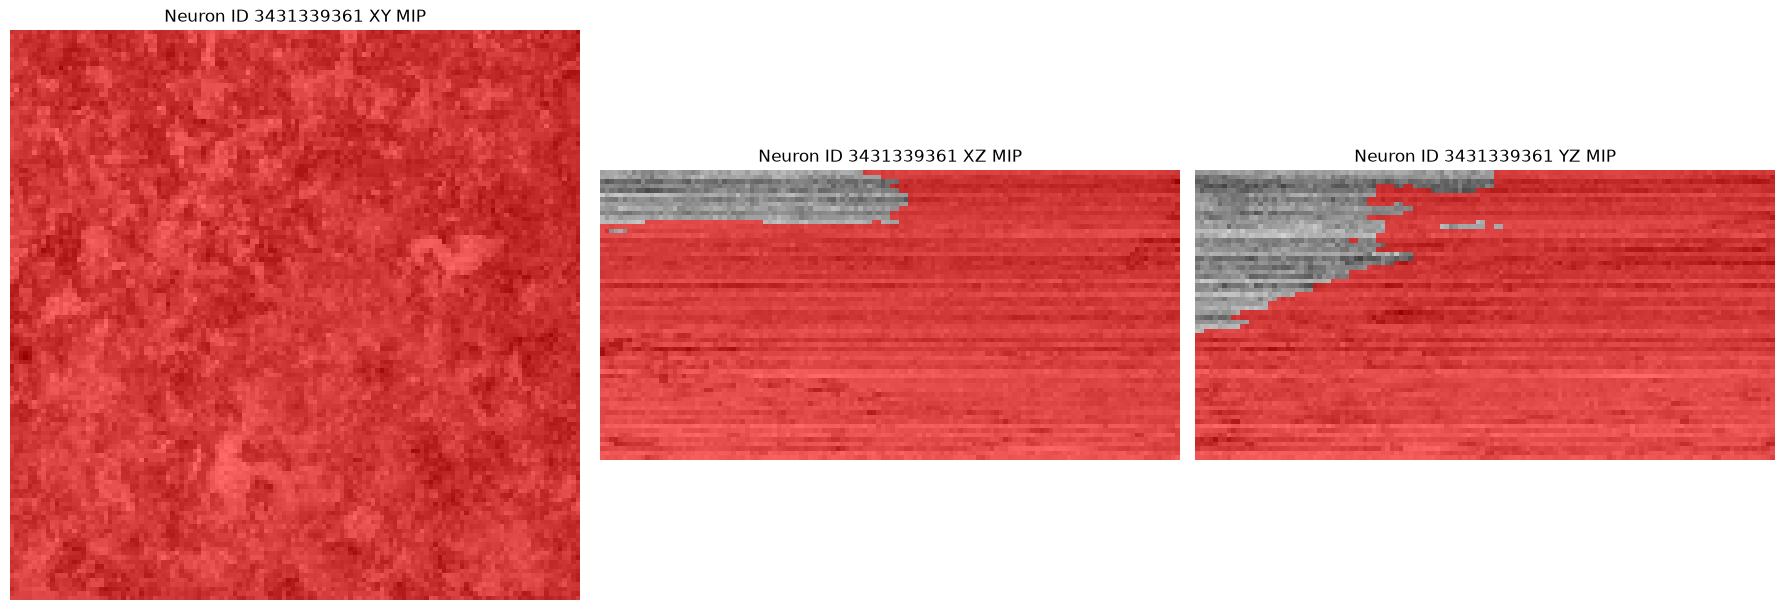

Selected neuron ID: 3431339361
Stitched volume shape: (64, 128, 128)
Neuron voxels: 664088


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

data_dir = Path('/root/project/data/fafb/blocks')
plane_blocks = [
    (0, 0, 0),
    (0, 0, 1),
    (0, 1, 0),
    (0, 1, 1),
]

def load_block(z, y, x):
    image_path = data_dir / f'image_z{z}_y{y}_x{x}.tif'
    segment_path = data_dir / f'segment_z{z}_y{y}_x{x}.tif'
    if not image_path.exists():
        raise FileNotFoundError(f'Missing image block: {image_path}')
    if not segment_path.exists():
        raise FileNotFoundError(f'Missing segment block: {segment_path}')
    return tiff.imread(image_path), tiff.imread(segment_path)

image_tiles = []
segment_tiles = []
for z, y, x in plane_blocks:
    image_volume, segment_volume = load_block(z, y, x)
    image_tiles.append(image_volume)
    segment_tiles.append(segment_volume)

stitched_image_top = np.concatenate([image_tiles[0], image_tiles[1]], axis=2)
stitched_image_bottom = np.concatenate([image_tiles[2], image_tiles[3]], axis=2)
stitched_image = np.concatenate([stitched_image_top, stitched_image_bottom], axis=1)

stitched_segment_top = np.concatenate([segment_tiles[0], segment_tiles[1]], axis=2)
stitched_segment_bottom = np.concatenate([segment_tiles[2], segment_tiles[3]], axis=2)
stitched_segment = np.concatenate([stitched_segment_top, stitched_segment_bottom], axis=1)

labels, counts = np.unique(stitched_segment, return_counts=True)
nonzero = labels != 0
if not np.any(nonzero):
    raise ValueError('No neuron labels found in the stitched blocks')

labels = labels[nonzero]
counts = counts[nonzero]
neuron_id = int(labels[np.argmax(counts)])

neuron_mask = stitched_segment == neuron_id
if not neuron_mask.any():
    raise ValueError(f'Neuron ID {neuron_id} not found in stitched volume')

def crop_to_content(image2d, mask2d, pad=8):
    coords = np.argwhere(mask2d)
    if coords.size == 0:
        return image2d, mask2d
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(image2d.shape[0], y1 + pad)
    x1 = min(image2d.shape[1], x1 + pad)
    return image2d[y0:y1, x0:x1], mask2d[y0:y1, x0:x1]

mip_xy = neuron_mask.max(axis=0)
mip_xz = neuron_mask.max(axis=1)
mip_yz = neuron_mask.max(axis=2)

img_xy = stitched_image.max(axis=0)
img_xz = stitched_image.max(axis=1)
img_yz = stitched_image.max(axis=2)

img_xy, mip_xy = crop_to_content(img_xy, mip_xy)
img_xz, mip_xz = crop_to_content(img_xz, mip_xz)
img_yz, mip_yz = crop_to_content(img_yz, mip_yz)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(img_xy, cmap='gray')
axs[0].imshow(np.where(mip_xy, 1.0, np.nan), cmap='autumn', alpha=0.6)
axs[0].set_title(f'Neuron ID {neuron_id} XY MIP')
axs[0].axis('off')

axs[1].imshow(img_xz, cmap='gray')
axs[1].imshow(np.where(mip_xz, 1.0, np.nan), cmap='autumn', alpha=0.6)
axs[1].set_title(f'Neuron ID {neuron_id} XZ MIP')
axs[1].axis('off')

axs[2].imshow(img_yz, cmap='gray')
axs[2].imshow(np.where(mip_yz, 1.0, np.nan), cmap='autumn', alpha=0.6)
axs[2].set_title(f'Neuron ID {neuron_id} YZ MIP')
axs[2].axis('off')

plt.tight_layout()
plt.savefig(f'neuron_{neuron_id}_stitched_mip_axes.png', dpi=300)
plt.show()

print(f'Selected neuron ID: {neuron_id}')
print(f'Stitched volume shape: {stitched_image.shape}')
print(f'Neuron voxels: {int(neuron_mask.sum())}')

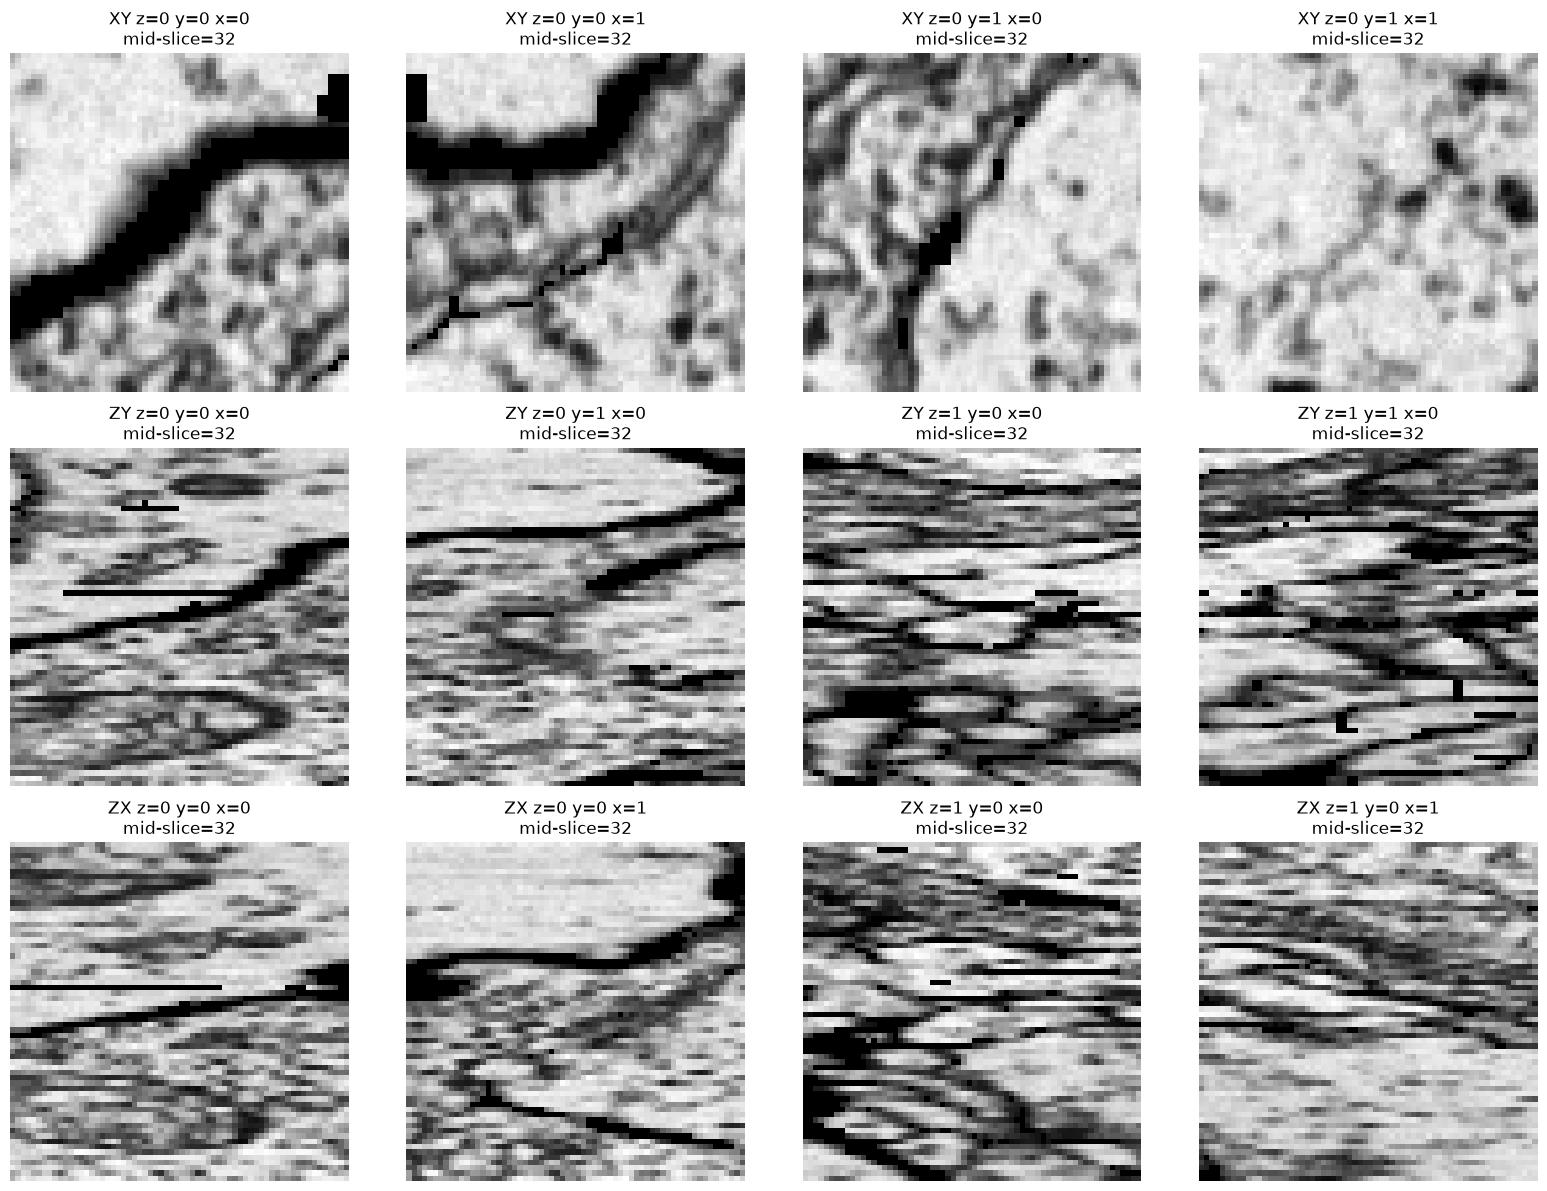

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

data_dir = Path('/root/project/data/fafb/blocks')

plane_blocks = {
    'xy': [
        (0, 0, 0),
        (0, 0, 1),
        (0, 1, 0),
        (0, 1, 1),
    ],
    'zy': [
        (0, 0, 0),
        (0, 1, 0),
        (1, 0, 0),
        (1, 1, 0),
    ],
    'zx': [
        (0, 0, 0),
        (0, 0, 1),
        (1, 0, 0),
        (1, 0, 1),
    ],
}

def load_segmented_volume(z, y, x):
    image_path = data_dir / f'image_z{z}_y{y}_x{x}.tif'
    segment_path = data_dir / f'segment_z{z}_y{y}_x{x}.tif'
    if not image_path.exists():
        raise FileNotFoundError(f'Missing image block: {image_path}')
    if not segment_path.exists():
        raise FileNotFoundError(f'Missing segment block: {segment_path}')
    image_volume = tiff.imread(image_path)
    segment_volume = tiff.imread(segment_path)
    segment_volume = (segment_volume != 0).astype(image_volume.dtype)
    return image_volume * segment_volume

slice_axis = {
    'xy': 0,
    'zy': 2,
    'zx': 1,
}

fig, axs = plt.subplots(3, 4, figsize=(16, 12))

for row, plane in enumerate(['xy', 'zy', 'zx']):
    axis = slice_axis[plane]
    for col, (z, y, x) in enumerate(plane_blocks[plane]):
        volume = load_segmented_volume(z, y, x)
        slice_index = volume.shape[axis] // 2
        if axis == 0:
            slice_image = volume[slice_index, :, :]
        elif axis == 1:
            slice_image = volume[:, slice_index, :]
        else:
            slice_image = volume[:, :, slice_index]

        axs[row, col].imshow(slice_image, cmap='gray')
        axs[row, col].set_title(f'{plane.upper()} z={z} y={y} x={x}\nmid-slice={slice_index}')
        axs[row, col].axis('off')

plt.tight_layout()
plt.show()

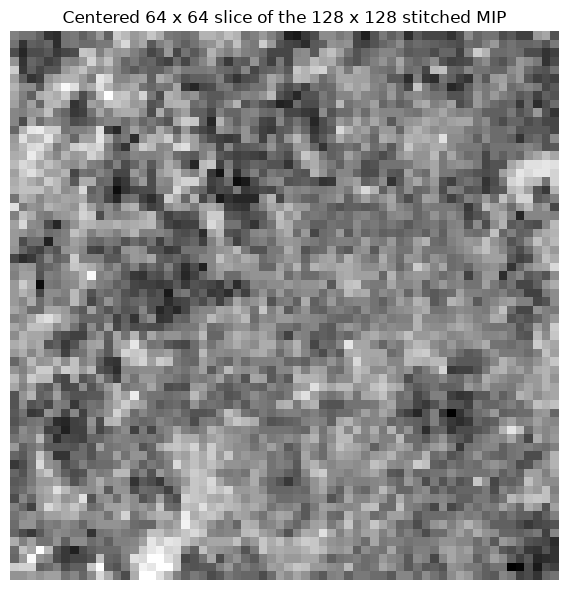

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

out_dir = Path('/root/project/models/3d-gaussians/mip_render_notebook')
out_dir.mkdir(parents=True, exist_ok=True)

crop_size = 64
height, width = rendered_128.shape
y0 = (height - crop_size) // 2
x0 = (width - crop_size) // 2
rendered_128_slice = rendered_128[y0:y0 + crop_size, x0:x0 + crop_size]

plt.figure(figsize=(6, 6))
plt.imshow(rendered_128_slice, cmap='gray')
plt.title('Centered 64 x 64 slice of the 128 x 128 stitched MIP')
plt.axis('off')
plt.tight_layout()
plt.savefig(out_dir / 'stitched_128x128_center_slice.png', dpi=300, bbox_inches='tight')
plt.show()